# 09 — Validate YOLO Silhouette ↔ Skeleton Alignment — FULL FIXED

এই notebook আপনার clean YOLO silhouette extraction শেষ হওয়ার পর run করবেন।

Fixed issue:

```text
NameError: name 'tqdm' is not defined
```

এই version-এ `tqdm` import/fallback properly added আছে।

This notebook validates:

```text
data/poses/<pose_tag>/
+
data/silhouettes/yolo11m_seg_64x44/
```

by sample key:

```text
subject + condition + seq + view
```

Main outputs:

```text
data/fusion_index/pose_index.csv
data/fusion_index/silhouette_index.csv
data/fusion_index/missing_modalities_report.csv
data/fusion_index/alignment_report.csv
data/fusion_index/multimodal_index.csv
data/fusion_index/fusion_alignment_summary.json

data/fusion_splits/train_LT_fusion.csv
data/fusion_splits/gallery_LT_fusion.csv
data/fusion_splits/probe_LT_nm_fusion.csv
data/fusion_splits/probe_LT_bg_fusion.csv
data/fusion_splits/probe_LT_cl_fusion.csv
data/fusion_splits/fusion_split_summary_clean.csv
```

Expected after clean YOLO extraction:

```text
Pose files       : 13640
Silhouette files : 13640
Matched samples  : 13640
```

Default filter:

```python
MIN_COMMON_FRAMES = 20
MIN_VALID_SIL_RATIO = 0.30
```

So very short/invalid samples are removed from clean fusion split files.

In [1]:
# ============================================================
# CELL 1 — Imports, paths, config
# ============================================================

from pathlib import Path
import json
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from tqdm.notebook import tqdm
except Exception:
    try:
        from tqdm import tqdm
    except Exception:
        # Last-resort fallback: tqdm(x) just returns x
        def tqdm(x, *args, **kwargs):
            return x

warnings.filterwarnings("ignore")

EXP_DIR = Path("/media/wadud/DriveUbuntu/GaitRecognition 2.0")

# Auto-detect largest pose folder unless you want to force a tag.
POSE_TAG = None
# Example:
# POSE_TAG = "yolo26l_pose"

# Clean YOLO silhouette extraction output tag.
SILHOUETTE_TAG = "yolo11m_seg_64x44"

POSES_DIR = EXP_DIR / "data" / "poses"
SILHOUETTES_DIR = EXP_DIR / "data" / "silhouettes"

SPLIT_DIR = EXP_DIR / "data" / "splits"
FUSION_INDEX_DIR = EXP_DIR / "data" / "fusion_index"
FUSION_SPLIT_DIR = EXP_DIR / "data" / "fusion_splits"
REPORT_DIR = EXP_DIR / "data" / "reports"

for d in [FUSION_INDEX_DIR, FUSION_SPLIT_DIR, REPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

EXPECTED_TOTAL = 124 * 10 * 11
EXPECTED_LT = {
    "train_LT_fusion.csv": 8140,
    "test_LT_fusion.csv": 5500,
    "gallery_LT_fusion.csv": 2200,
    "probe_LT_nm_fusion.csv": 1100,
    "probe_LT_bg_fusion.csv": 1100,
    "probe_LT_cl_fusion.csv": 1100,
}

# Clean multimodal filter.
# Keep 20 as default. The 3 dropped samples in your previous run were likely T_common < 20.
MIN_COMMON_FRAMES = 20
MIN_VALID_SIL_RATIO = 0.30

print("=" * 80)
print("YOLO Silhouette ↔ Skeleton Alignment Validation — FULL FIXED")
print("=" * 80)
print("EXP_DIR        :", EXP_DIR)
print("POSE_TAG       :", POSE_TAG)
print("SILHOUETTE_TAG :", SILHOUETTE_TAG)
print("MIN_COMMON_FRAMES:", MIN_COMMON_FRAMES)
print("MIN_VALID_SIL_RATIO:", MIN_VALID_SIL_RATIO)
print("=" * 80)

assert EXP_DIR.exists(), f"EXP_DIR not found: {EXP_DIR}"
assert SPLIT_DIR.exists(), f"SPLIT_DIR not found: {SPLIT_DIR}"

YOLO Silhouette ↔ Skeleton Alignment Validation — FULL FIXED
EXP_DIR        : /media/wadud/DriveUbuntu/GaitRecognition 2.0
POSE_TAG       : None
SILHOUETTE_TAG : yolo11m_seg_64x44
MIN_COMMON_FRAMES: 20
MIN_VALID_SIL_RATIO: 0.3


In [2]:
# ============================================================
# CELL 2 — Detect pose root and silhouette root
# ============================================================

def count_npz_files(root: Path):
    if not root.exists():
        return 0
    return len(list(root.rglob("*.npz")))

def detect_largest_child(root: Path, tag=None):
    if tag is not None:
        p = root / tag
        if not p.exists():
            raise FileNotFoundError(f"Requested folder does not exist: {p}")
        return p

    if not root.exists():
        raise FileNotFoundError(f"Root folder does not exist: {root}")

    candidates = [p for p in root.iterdir() if p.is_dir()]
    if not candidates:
        raise FileNotFoundError(f"No subfolders found under: {root}")

    counts = [(count_npz_files(p), p) for p in candidates]
    counts.sort(reverse=True, key=lambda x: x[0])

    print("Candidate folders under:", root)
    for count, p in counts:
        print(f"  {p.name}: {count} .npz files")

    return counts[0][1]

POSE_ROOT = detect_largest_child(POSES_DIR, POSE_TAG)
SIL_ROOT = detect_largest_child(SILHOUETTES_DIR, SILHOUETTE_TAG)

pose_count = count_npz_files(POSE_ROOT)
sil_count = count_npz_files(SIL_ROOT)

print()
print("Selected POSE_ROOT:", POSE_ROOT)
print("Selected SIL_ROOT :", SIL_ROOT)
print("Pose files        :", pose_count)
print("Silhouette files  :", sil_count)
print("Expected total    :", EXPECTED_TOTAL)

if pose_count != EXPECTED_TOTAL:
    print(f"[WARNING] Pose count is {pose_count}, expected {EXPECTED_TOTAL}")
if sil_count != EXPECTED_TOTAL:
    print(f"[WARNING] Silhouette count is {sil_count}, expected {EXPECTED_TOTAL}")

Candidate folders under: /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/poses
  yolo26l_pose: 13640 .npz files

Selected POSE_ROOT: /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/poses/yolo26l_pose
Selected SIL_ROOT : /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/silhouettes/yolo11m_seg_64x44
Pose files        : 13640
Silhouette files  : 13640
Expected total    : 13640


In [3]:
# ============================================================
# CELL 3 — Build pose/silhouette indexes
# ============================================================

def record_from_modal_path(path: Path, root: Path, modal_name: str):
    rel = path.relative_to(root)

    if len(rel.parts) < 3:
        raise ValueError(f"Unexpected {modal_name} path structure: {path}")

    subject = str(rel.parts[0])
    condition_seq = str(rel.parts[1])
    view = str(path.stem)

    if "-" not in condition_seq:
        raise ValueError(f"Unexpected condition-seq folder: {condition_seq}")

    condition, seq = condition_seq.split("-", 1)

    return {
        "subject": subject,
        "condition": condition,
        "seq": seq,
        "view": view,
        "condition_seq": condition_seq,
        "key": f"{subject}-{condition}-{seq}-{view}",
        f"{modal_name}_path": str(path),
    }

pose_files = sorted(POSE_ROOT.rglob("*.npz"))
sil_files = sorted(SIL_ROOT.rglob("*.npz"))

pose_records = []
sil_records = []
bad_pose = []
bad_sil = []

for p in pose_files:
    try:
        pose_records.append(record_from_modal_path(p, POSE_ROOT, "pose"))
    except Exception as e:
        bad_pose.append({"path": str(p), "error": str(e)})

for p in sil_files:
    try:
        sil_records.append(record_from_modal_path(p, SIL_ROOT, "silhouette"))
    except Exception as e:
        bad_sil.append({"path": str(p), "error": str(e)})

df_pose = pd.DataFrame(pose_records)
df_sil = pd.DataFrame(sil_records)

pose_index_csv = FUSION_INDEX_DIR / "pose_index.csv"
sil_index_csv = FUSION_INDEX_DIR / "silhouette_index.csv"

df_pose.to_csv(pose_index_csv, index=False)
df_sil.to_csv(sil_index_csv, index=False)

if bad_pose:
    pd.DataFrame(bad_pose).to_csv(FUSION_INDEX_DIR / "bad_pose_paths.csv", index=False)
if bad_sil:
    pd.DataFrame(bad_sil).to_csv(FUSION_INDEX_DIR / "bad_silhouette_paths.csv", index=False)

print("Pose index rows      :", len(df_pose))
print("Silhouette index rows:", len(df_sil))
print("Bad pose paths       :", len(bad_pose))
print("Bad silhouette paths :", len(bad_sil))
print("Saved:", pose_index_csv)
print("Saved:", sil_index_csv)

display(df_pose.head())
display(df_sil.head())

Pose index rows      : 13640
Silhouette index rows: 13640
Bad pose paths       : 0
Bad silhouette paths : 0
Saved: /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/fusion_index/pose_index.csv
Saved: /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/fusion_index/silhouette_index.csv


,subject,condition,seq,view,condition_seq,key,pose_path
0,001,bg,01,000,bg-01,001-bg-01-000,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...
1,001,bg,01,018,bg-01,001-bg-01-018,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...
2,001,bg,01,036,bg-01,001-bg-01-036,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...
3,001,bg,01,054,bg-01,001-bg-01-054,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...
4,001,bg,01,072,bg-01,001-bg-01-072,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...


,subject,condition,seq,view,condition_seq,key,silhouette_path
0,001,bg,01,000,bg-01,001-bg-01-000,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...
1,001,bg,01,018,bg-01,001-bg-01-018,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...
2,001,bg,01,036,bg-01,001-bg-01-036,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...
3,001,bg,01,054,bg-01,001-bg-01-054,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...
4,001,bg,01,072,bg-01,001-bg-01-072,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...


In [4]:
# ============================================================
# CELL 4 — Duplicate key check
# ============================================================

def check_duplicate_keys(df, name):
    dup = df[df.duplicated("key", keep=False)].sort_values("key")
    print(f"{name} duplicate rows:", len(dup))

    if len(dup) > 0:
        dup_csv = FUSION_INDEX_DIR / f"{name}_duplicate_keys.csv"
        dup.to_csv(dup_csv, index=False)
        print("Saved duplicate report:", dup_csv)
        display(dup.head(20))

check_duplicate_keys(df_pose, "pose")
check_duplicate_keys(df_sil, "silhouette")

assert not df_pose.duplicated("key").any(), "Pose index has duplicate sample keys."
assert not df_sil.duplicated("key").any(), "Silhouette index has duplicate sample keys."

pose duplicate rows: 0
silhouette duplicate rows: 0


In [5]:
# ============================================================
# CELL 5 — Match by sample key
# ============================================================

merge_keys = ["subject", "condition", "seq", "view", "condition_seq", "key"]

df_all = pd.merge(
    df_pose,
    df_sil,
    on=merge_keys,
    how="outer",
    indicator=True,
)

df_matched = df_all[df_all["_merge"] == "both"].copy()
df_pose_only = df_all[df_all["_merge"] == "left_only"].copy()
df_sil_only = df_all[df_all["_merge"] == "right_only"].copy()

missing_modalities_csv = FUSION_INDEX_DIR / "missing_modalities_report.csv"
df_all.to_csv(missing_modalities_csv, index=False)

print("Matched samples :", len(df_matched))
print("Pose only       :", len(df_pose_only))
print("Silhouette only :", len(df_sil_only))
print("Expected total  :", EXPECTED_TOTAL)
print("Saved:", missing_modalities_csv)

if len(df_pose_only) > 0:
    print("\nPose-only examples:")
    display(df_pose_only.head(20))

if len(df_sil_only) > 0:
    print("\nSilhouette-only examples:")
    display(df_sil_only.head(20))

Matched samples : 13640
Pose only       : 0
Silhouette only : 0
Expected total  : 13640
Saved: /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/fusion_index/missing_modalities_report.csv


In [6]:
# ============================================================
# CELL 6 — Read metadata: frame count + YOLO quality
# ============================================================

def read_pose_meta(path):
    try:
        data = np.load(path)

        if "keypoints_norm_filled" not in data.files:
            return {
                "T_pose": 0,
                "pose_shape": "",
                "pose_error": "missing keypoints_norm_filled",
            }

        X = data["keypoints_norm_filled"]

        return {
            "T_pose": int(X.shape[0]),
            "pose_shape": str(tuple(X.shape)),
            "pose_error": "",
        }

    except Exception as e:
        return {
            "T_pose": 0,
            "pose_shape": "",
            "pose_error": str(e),
        }

def read_sil_meta(path):
    try:
        data = np.load(path)

        if "silhouettes" not in data.files:
            return {
                "T_silhouette": 0,
                "silhouette_shape": "",
                "sil_valid_frame_ratio": 0.0,
                "sil_mean_det_score": 0.0,
                "sil_mean_mask_area": 0.0,
                "silhouette_error": "missing silhouettes",
            }

        S = data["silhouettes"]
        T = int(S.shape[0])

        if "frame_valid" in data.files:
            frame_valid = data["frame_valid"].astype(bool)
        else:
            frame_valid = np.ones((T,), dtype=bool)

        if "det_scores" in data.files:
            det_scores = data["det_scores"].astype(np.float32)
            mean_det_score = float(np.nanmean(det_scores)) if len(det_scores) else 0.0
        else:
            mean_det_score = np.nan

        if "mask_areas" in data.files:
            mask_areas = data["mask_areas"].astype(np.float32)
            mean_mask_area = float(np.nanmean(mask_areas)) if len(mask_areas) else 0.0
        elif "foreground_areas" in data.files:
            mask_areas = data["foreground_areas"].astype(np.float32)
            mean_mask_area = float(np.nanmean(mask_areas)) if len(mask_areas) else 0.0
        else:
            mean_mask_area = float((S > 0).sum(axis=(1, 2)).mean()) if len(S) else 0.0

        return {
            "T_silhouette": T,
            "silhouette_shape": str(tuple(S.shape)),
            "sil_valid_frame_ratio": float(frame_valid.mean()) if len(frame_valid) else 0.0,
            "sil_mean_det_score": mean_det_score,
            "sil_mean_mask_area": mean_mask_area,
            "silhouette_error": "",
        }

    except Exception as e:
        return {
            "T_silhouette": 0,
            "silhouette_shape": "",
            "sil_valid_frame_ratio": 0.0,
            "sil_mean_det_score": 0.0,
            "sil_mean_mask_area": 0.0,
            "silhouette_error": str(e),
        }

rows = []

for _, row in tqdm(df_matched.iterrows(), total=len(df_matched), desc="Reading pose/silhouette metadata"):
    pose_meta = read_pose_meta(row["pose_path"])
    sil_meta = read_sil_meta(row["silhouette_path"])

    T_pose = int(pose_meta["T_pose"])
    T_sil = int(sil_meta["T_silhouette"])

    T_common = min(T_pose, T_sil)
    T_diff = abs(T_pose - T_sil)

    if T_pose == 0 or T_sil == 0:
        status = "read_error"
    elif T_diff == 0:
        status = "exact"
    elif T_diff <= 2:
        status = "small_mismatch"
    else:
        status = "large_mismatch"

    rows.append({
        "key": row["key"],
        "subject": row["subject"],
        "condition": row["condition"],
        "seq": row["seq"],
        "view": row["view"],
        "condition_seq": row["condition_seq"],
        "pose_path": row["pose_path"],
        "silhouette_path": row["silhouette_path"],
        **pose_meta,
        **sil_meta,
        "T_common": T_common,
        "T_diff": T_diff,
        "alignment_status": status,
    })

df_align = pd.DataFrame(rows)

alignment_csv = FUSION_INDEX_DIR / "alignment_report.csv"
df_align.to_csv(alignment_csv, index=False)

print("Saved alignment report:", alignment_csv)

print("\nAlignment status:")
display(df_align["alignment_status"].value_counts())

print("\nFrame and quality summary:")
display(df_align[[
    "T_pose",
    "T_silhouette",
    "T_common",
    "T_diff",
    "sil_valid_frame_ratio",
    "sil_mean_det_score",
    "sil_mean_mask_area",
]].describe())

display(df_align.head())

Reading pose/silhouette metadata:   0%|          | 0/13640 [00:00<?, ?it/s]

Saved alignment report: /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/fusion_index/alignment_report.csv

Alignment status:


alignment_status
exact    13640
Name: count, dtype: int64


Frame and quality summary:


,T_pose,T_silhouette,T_common,T_diff,sil_valid_frame_ratio,sil_mean_det_score,sil_mean_mask_area
count,13640.000000,13640.000000,13640.000000,13640.0,13640.000000,13640.000000,13640.000000
mean,120.973974,120.973974,120.973974,0.0,0.848504,0.758749,3418.415194
std,21.729111,21.729111,21.729111,0.0,0.144987,0.136940,1949.132130
min,12.000000,12.000000,12.000000,0.0,0.000000,0.000000,0.000000
25%,106.000000,106.000000,106.000000,0.0,0.722689,0.639307,2234.760864
50%,119.000000,119.000000,119.000000,0.0,0.877121,0.779515,2835.312012
75%,134.000000,134.000000,134.000000,0.0,1.000000,0.899471,3966.557007
max,311.000000,311.000000,311.000000,0.0,1.000000,0.939616,26427.654297


,key,subject,condition,seq,view,condition_seq,pose_path,silhouette_path,T_pose,pose_shape,pose_error,T_silhouette,silhouette_shape,sil_valid_frame_ratio,sil_mean_det_score,sil_mean_mask_area,silhouette_error,T_common,T_diff,alignment_status
0,001-bg-01-000,001,bg,01,000,bg-01,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,99,"(99, 17, 2)",,99,"(99, 64, 44)",1.000000,0.910541,4039.515137,,99,0,exact
1,001-bg-01-018,001,bg,01,018,bg-01,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,102,"(102, 17, 2)",,102,"(102, 64, 44)",1.000000,0.905187,4417.048828,,102,0,exact
2,001-bg-01-036,001,bg,01,036,bg-01,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,99,"(99, 17, 2)",,99,"(99, 64, 44)",0.969697,0.862985,3496.373779,,99,0,exact
3,001-bg-01-054,001,bg,01,054,bg-01,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,106,"(106, 17, 2)",,106,"(106, 64, 44)",0.943396,0.839839,2664.773682,,106,0,exact
4,001-bg-01-072,001,bg,01,072,bg-01,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,106,"(106, 17, 2)",,106,"(106, 64, 44)",0.811321,0.682147,2239.179199,,106,0,exact


In [7]:
# ============================================================
# CELL 7 — Create clean multimodal index
# ============================================================

SAFE_STATUSES = {"exact", "small_mismatch", "large_mismatch"}

df_multi = df_align[df_align["alignment_status"].isin(SAFE_STATUSES)].copy()
df_multi = df_multi[df_multi["T_common"] >= MIN_COMMON_FRAMES].copy()
df_multi = df_multi[df_multi["sil_valid_frame_ratio"] >= MIN_VALID_SIL_RATIO].copy()

multimodal_csv = FUSION_INDEX_DIR / "multimodal_index.csv"
df_multi.to_csv(multimodal_csv, index=False)

print("Matched samples          :", len(df_matched))
print("Usable multimodal samples:", len(df_multi))
print("Dropped from matched     :", len(df_matched) - len(df_multi))
print("Expected total           :", EXPECTED_TOTAL)
print("Saved:", multimodal_csv)

print("\nUsable alignment status:")
display(df_multi["alignment_status"].value_counts())

if len(df_multi) < len(df_matched):
    missing_keys = set(df_matched["key"]) - set(df_multi["key"])
    df_dropped = df_align[df_align["key"].isin(missing_keys)].copy()
    dropped_csv = FUSION_INDEX_DIR / "dropped_multimodal_keys.csv"
    df_dropped.to_csv(dropped_csv, index=False)

    print("\nDropped multimodal keys:")
    display(df_dropped[[
        "key", "subject", "condition", "seq", "view",
        "T_pose", "T_silhouette", "T_common", "T_diff",
        "sil_valid_frame_ratio", "sil_mean_det_score",
        "pose_path", "silhouette_path"
    ]])
    print("Saved:", dropped_csv)

Matched samples          : 13640
Usable multimodal samples: 13636
Dropped from matched     : 4
Expected total           : 13640
Saved: /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/fusion_index/multimodal_index.csv

Usable alignment status:


alignment_status
exact    13636
Name: count, dtype: int64


Dropped multimodal keys:


,key,subject,condition,seq,view,T_pose,T_silhouette,T_common,T_diff,sil_valid_frame_ratio,sil_mean_det_score,pose_path,silhouette_path
532,005-nm-05-072,005,nm,05,072,302,302,302,0,0.294702,0.257335,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...
11931,109-nm-01-126,109,nm,01,126,12,12,12,0,0.833333,0.609416,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...
11932,109-nm-01-144,109,nm,01,144,19,19,19,0,0.000000,0.000000,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...
11933,109-nm-01-162,109,nm,01,162,14,14,14,0,1.000000,0.850656,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...


Saved: /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/fusion_index/dropped_multimodal_keys.csv


In [8]:
# ============================================================
# CELL 8 — Condition/view distribution checks
# ============================================================

print("Counts by condition-seq:")
display(
    df_multi
    .groupby(["condition", "seq"])
    .size()
    .reset_index(name="count")
    .sort_values(["condition", "seq"])
)

print("Counts by view:")
display(
    df_multi
    .groupby("view")
    .size()
    .reset_index(name="count")
    .sort_values("view")
)

print("Counts by condition and view:")
display(
    df_multi
    .groupby(["condition", "view"])
    .size()
    .reset_index(name="count")
    .sort_values(["condition", "view"])
)

Counts by condition-seq:


,condition,seq,count
0,bg,01,1364
1,bg,02,1364
2,cl,01,1364
3,cl,02,1364
4,nm,01,1361
5,nm,02,1364
6,nm,03,1364
7,nm,04,1364
8,nm,05,1363
9,nm,06,1364


Counts by view:


,view,count
0,000,1240
1,018,1240
2,036,1240
3,054,1240
4,072,1239
5,090,1240
6,108,1240
7,126,1239
8,144,1239
9,162,1239


Counts by condition and view:


,condition,view,count
0,bg,000,248
1,bg,018,248
2,bg,036,248
3,bg,054,248
4,bg,072,248
5,bg,090,248
6,bg,108,248
7,bg,126,248
8,bg,144,248
9,bg,162,248


In [9]:
# ============================================================
# CELL 9 — Low-quality silhouette report
# ============================================================

low_quality = df_align[
    (pd.to_numeric(df_align["sil_valid_frame_ratio"], errors="coerce") < 0.50) |
    (pd.to_numeric(df_align["sil_mean_det_score"], errors="coerce") < 0.25)
].copy()

low_quality_csv = REPORT_DIR / "yolo_silhouette_low_quality_alignment_samples.csv"
low_quality.to_csv(low_quality_csv, index=False)

print("Low-quality samples:", len(low_quality))
print("Saved:", low_quality_csv)

if len(low_quality) > 0:
    display(low_quality[[
        "key", "subject", "condition", "seq", "view",
        "T_common", "sil_valid_frame_ratio", "sil_mean_det_score",
        "sil_mean_mask_area", "silhouette_path"
    ]].head(50))

Low-quality samples: 96
Saved: /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/reports/yolo_silhouette_low_quality_alignment_samples.csv


,key,subject,condition,seq,view,T_common,sil_valid_frame_ratio,sil_mean_det_score,sil_mean_mask_area,silhouette_path
370,004-cl-02-126,004,cl,02,126,87,0.459770,0.414680,1712.701172,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...
444,005-bg-01-072,005,bg,01,072,187,0.481283,0.403222,1513.379639,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...
445,005-bg-01-090,005,bg,01,090,186,0.467742,0.389008,1468.129028,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...
446,005-bg-01-108,005,bg,01,108,180,0.494444,0.408400,1467.155518,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...
466,005-cl-01-072,005,cl,01,072,202,0.405941,0.347353,1529.237671,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...
467,005-cl-01-090,005,cl,01,090,206,0.417476,0.344273,1489.014526,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...
468,005-cl-01-108,005,cl,01,108,198,0.424242,0.365331,1498.095947,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...
469,005-cl-01-126,005,cl,01,126,206,0.446602,0.395145,1572.271851,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...
470,005-cl-01-144,005,cl,01,144,210,0.438095,0.371849,1859.438110,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...
477,005-cl-02-072,005,cl,02,072,204,0.416667,0.354400,1481.573486,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...


In [10]:
# ============================================================
# CELL 10 — Create CLEAN fusion split CSV files
# ============================================================

split_files = [
    "train_ST.csv", "test_ST.csv", "gallery_ST.csv", "probe_ST_nm.csv", "probe_ST_bg.csv", "probe_ST_cl.csv",
    "train_MT.csv", "test_MT.csv", "gallery_MT.csv", "probe_MT_nm.csv", "probe_MT_bg.csv", "probe_MT_cl.csv",
    "train_LT.csv", "test_LT.csv", "gallery_LT.csv", "probe_LT_nm.csv", "probe_LT_bg.csv", "probe_LT_cl.csv",
]

csv_dtype = {
    "pose_path": str,
    "subject": str,
    "condition": str,
    "seq": str,
    "view": str,
}

lookup_cols = [
    "subject", "condition", "seq", "view",
    "pose_path", "silhouette_path",
    "T_pose", "T_silhouette", "T_common", "T_diff",
    "alignment_status",
    "sil_valid_frame_ratio",
    "sil_mean_det_score",
    "sil_mean_mask_area",
]

df_lookup = df_multi[lookup_cols].copy()

summary_rows = []
created_paths = []

for filename in split_files:
    src = SPLIT_DIR / filename

    if not src.exists():
        print("[SKIP missing]", src)
        continue

    df_split = pd.read_csv(src, dtype=csv_dtype)

    # Keep original pose path from split for debugging missing rows.
    df_split_work = df_split.copy()
    if "pose_path" in df_split_work.columns:
        df_split_work = df_split_work.rename(columns={"pose_path": "split_pose_path"})

    df_merge = pd.merge(
        df_split_work,
        df_lookup,
        on=["subject", "condition", "seq", "view"],
        how="left",
        indicator=True,
    )

    # IMPORTANT FIX:
    # Save only matched rows to *_fusion.csv.
    # Missing rows are saved separately and are NOT included in the clean split.
    df_clean = df_merge[df_merge["_merge"] == "both"].drop(columns=["_merge"]).copy()
    df_missing = df_merge[df_merge["_merge"] != "both"].drop(columns=["_merge"]).copy()

    out_name = filename.replace(".csv", "_fusion.csv")
    out_path = FUSION_SPLIT_DIR / out_name
    df_clean.to_csv(out_path, index=False)
    created_paths.append(out_path)

    missing_path = ""
    if len(df_missing) > 0:
        missing_path = FUSION_SPLIT_DIR / filename.replace(".csv", "_missing_multimodal.csv")
        df_missing.to_csv(missing_path, index=False)

    summary_rows.append({
        "source_split": filename,
        "source_rows": len(df_split),
        "fusion_rows_clean": len(df_clean),
        "missing_rows": len(df_missing),
        "out_csv": str(out_path),
        "missing_csv": str(missing_path),
    })

df_split_summary = pd.DataFrame(summary_rows)
split_summary_csv = FUSION_SPLIT_DIR / "fusion_split_summary_clean.csv"
df_split_summary.to_csv(split_summary_csv, index=False)

print("Fusion split summary:")
display(df_split_summary)
print("Saved:", split_summary_csv)

print("\nCreated clean fusion split files:")
for p in created_paths:
    print("-", p)

Fusion split summary:


,source_split,source_rows,fusion_rows_clean,missing_rows,out_csv,missing_csv
0,train_ST.csv,2640,2639,1,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...
1,test_ST.csv,11000,10997,3,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...
2,gallery_ST.csv,4400,4397,3,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...
3,probe_ST_nm.csv,2200,2200,0,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,
4,probe_ST_bg.csv,2200,2200,0,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,
5,probe_ST_cl.csv,2200,2200,0,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,
6,train_MT.csv,6820,6819,1,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...
7,test_MT.csv,6820,6817,3,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...
8,gallery_MT.csv,2728,2725,3,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...
9,probe_MT_nm.csv,1364,1364,0,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,


Saved: /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/fusion_splits/fusion_split_summary_clean.csv

Created clean fusion split files:
- /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/fusion_splits/train_ST_fusion.csv
- /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/fusion_splits/test_ST_fusion.csv
- /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/fusion_splits/gallery_ST_fusion.csv
- /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/fusion_splits/probe_ST_nm_fusion.csv
- /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/fusion_splits/probe_ST_bg_fusion.csv
- /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/fusion_splits/probe_ST_cl_fusion.csv
- /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/fusion_splits/train_MT_fusion.csv
- /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/fusion_splits/test_MT_fusion.csv
- /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/fusion_splits/gallery_MT_fusion.csv
- /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/fusion_splits/probe_MT_nm_

In [11]:
# ============================================================
# CELL 11 — LT split count check
# ============================================================

print("LT fusion split count check:")

for fname, expected in EXPECTED_LT.items():
    p = FUSION_SPLIT_DIR / fname
    if p.exists():
        df = pd.read_csv(p, dtype=str)
        missing = expected - len(df)
        print(f"{fname:28s} rows={len(df):5d} expected={expected:5d} missing={missing:3d} subjects={df['subject'].nunique():3d}")
    else:
        print("[MISSING]", fname)

LT fusion split count check:
train_LT_fusion.csv          rows= 8139 expected= 8140 missing=  1 subjects= 74
test_LT_fusion.csv           rows= 5497 expected= 5500 missing=  3 subjects= 50
gallery_LT_fusion.csv        rows= 2197 expected= 2200 missing=  3 subjects= 50
probe_LT_nm_fusion.csv       rows= 1100 expected= 1100 missing=  0 subjects= 50
probe_LT_bg_fusion.csv       rows= 1100 expected= 1100 missing=  0 subjects= 50
probe_LT_cl_fusion.csv       rows= 1100 expected= 1100 missing=  0 subjects= 50


In [12]:
# ============================================================
# CELL 12 — Display LT missing rows if any
# ============================================================

for name in [
    "gallery_LT_missing_multimodal.csv",
    "test_LT_missing_multimodal.csv",
    "train_LT_missing_multimodal.csv",
    "probe_LT_nm_missing_multimodal.csv",
    "probe_LT_bg_missing_multimodal.csv",
    "probe_LT_cl_missing_multimodal.csv",
]:
    p = FUSION_SPLIT_DIR / name

    if p.exists():
        print("\n" + name)
        df = pd.read_csv(p, dtype=str)
        cols = [c for c in [
            "subject", "condition", "seq", "view",
            "split_pose_path", "pose_path", "silhouette_path",
            "T_common", "alignment_status", "sil_valid_frame_ratio", "sil_mean_det_score"
        ] if c in df.columns]
        display(df[cols])


gallery_LT_missing_multimodal.csv


,subject,condition,seq,view,split_pose_path,pose_path,silhouette_path,T_common,alignment_status,sil_valid_frame_ratio,sil_mean_det_score
0,109,nm,01,126,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,NaN,NaN,NaN,NaN,NaN,NaN
1,109,nm,01,144,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,NaN,NaN,NaN,NaN,NaN,NaN
2,109,nm,01,162,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,NaN,NaN,NaN,NaN,NaN,NaN



test_LT_missing_multimodal.csv


,subject,condition,seq,view,split_pose_path,pose_path,silhouette_path,T_common,alignment_status,sil_valid_frame_ratio,sil_mean_det_score
0,109,nm,01,126,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,NaN,NaN,NaN,NaN,NaN,NaN
1,109,nm,01,144,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,NaN,NaN,NaN,NaN,NaN,NaN
2,109,nm,01,162,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,NaN,NaN,NaN,NaN,NaN,NaN



train_LT_missing_multimodal.csv


,subject,condition,seq,view,split_pose_path,pose_path,silhouette_path,T_common,alignment_status,sil_valid_frame_ratio,sil_mean_det_score
0,005,nm,05,072,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,NaN,NaN,NaN,NaN,NaN,NaN


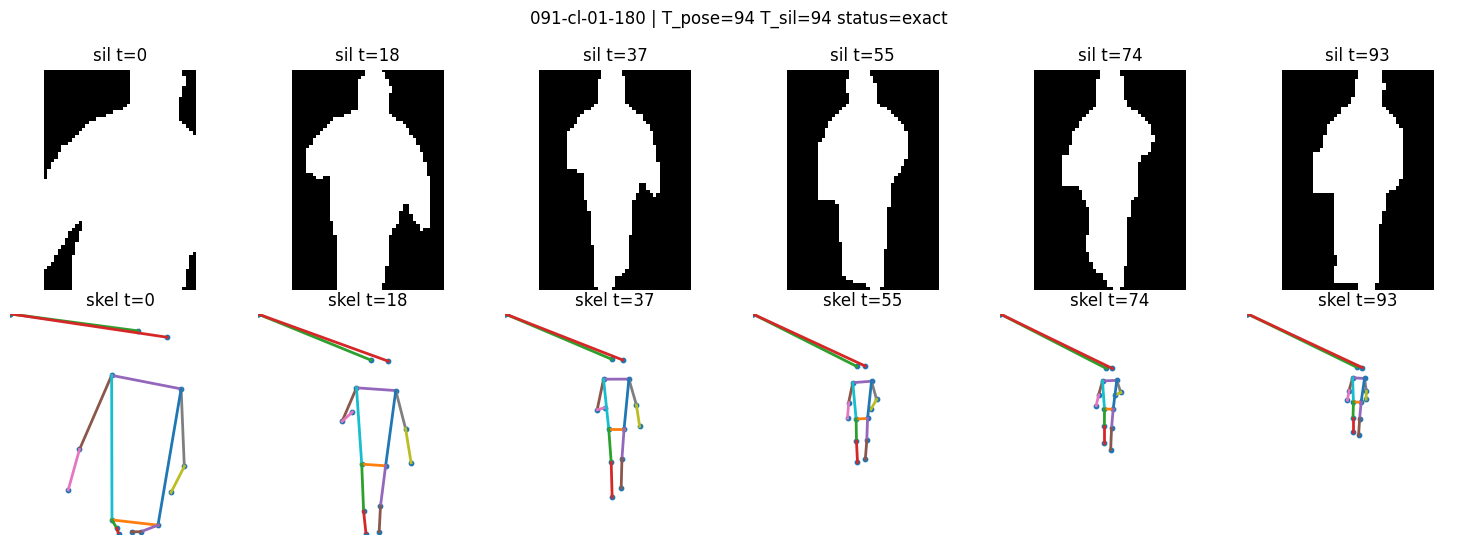

In [13]:
# ============================================================
# CELL 13 — Visual sanity check: same sample skeleton and silhouette
# ============================================================

COCO_EDGES = [
    (0, 1), (0, 2),
    (1, 3), (2, 4),
    (5, 6),
    (5, 7), (7, 9),
    (6, 8), (8, 10),
    (5, 11), (6, 12),
    (11, 12),
    (11, 13), (13, 15),
    (12, 14), (14, 16),
]

def plot_sample_alignment(row, num_frames=6):
    pose_data = np.load(row["pose_path"])
    sil_data = np.load(row["silhouette_path"])

    X = pose_data["keypoints_norm_filled"].astype(np.float32)
    S = sil_data["silhouettes"].astype(np.uint8)

    T = min(len(X), len(S))
    if T <= 0:
        print("Empty sample:", row["key"])
        return

    frame_ids = np.linspace(0, T - 1, num=min(num_frames, T)).astype(int)

    fig, axes = plt.subplots(2, len(frame_ids), figsize=(2.5 * len(frame_ids), 5.5))

    if len(frame_ids) == 1:
        axes = np.array([[axes[0]], [axes[1]]])

    for i, t in enumerate(frame_ids):
        ax0 = axes[0, i]
        ax0.imshow(S[t], cmap="gray")
        ax0.set_title(f"sil t={t}")
        ax0.axis("off")

        pts = X[t]
        ax1 = axes[1, i]

        for a, b in COCO_EDGES:
            ax1.plot([pts[a, 0], pts[b, 0]], [pts[a, 1], pts[b, 1]], linewidth=2)

        ax1.scatter(pts[:, 0], pts[:, 1], s=10)
        ax1.set_xlim(0, 1)
        ax1.set_ylim(1, 0)
        ax1.set_aspect("equal")
        ax1.set_title(f"skel t={t}")
        ax1.axis("off")

    fig.suptitle(
        f"{row['key']} | T_pose={row['T_pose']} T_sil={row['T_silhouette']} status={row['alignment_status']}"
    )
    fig.tight_layout()
    plt.show()

if len(df_multi) == 0:
    print("No multimodal samples found.")
else:
    sample_row = df_multi.sample(1, random_state=42).iloc[0]
    plot_sample_alignment(sample_row, num_frames=6)

In [14]:
# ============================================================
# CELL 14 — Fusion loader dry-run
# ============================================================

def crop_pair_for_fusion(pose_path, silhouette_path, seq_len=60, random_crop=True):
    pose_data = np.load(pose_path)
    sil_data = np.load(silhouette_path)

    X = pose_data["keypoints_norm_filled"].astype(np.float32)
    S = sil_data["silhouettes"].astype(np.uint8)

    T = min(len(X), len(S))
    if T <= 0:
        raise ValueError("Empty pose/silhouette sequence.")

    X = X[:T]
    S = S[:T]

    if T >= seq_len:
        if random_crop:
            start = np.random.randint(0, T - seq_len + 1)
        else:
            start = max(0, (T - seq_len) // 2)

        X_clip = X[start:start + seq_len]
        S_clip = S[start:start + seq_len]
    else:
        pad_len = seq_len - T
        X_pad = np.repeat(X[-1:], pad_len, axis=0)
        S_pad = np.repeat(S[-1:], pad_len, axis=0)

        X_clip = np.concatenate([X, X_pad], axis=0)
        S_clip = np.concatenate([S, S_pad], axis=0)

    return X_clip, S_clip

lt_train_fusion = FUSION_SPLIT_DIR / "train_LT_fusion.csv"

if lt_train_fusion.exists():
    df_train_fusion = pd.read_csv(lt_train_fusion, dtype=str)
    row = df_train_fusion.iloc[0]

    X_clip, S_clip = crop_pair_for_fusion(
        row["pose_path"],
        row["silhouette_path"],
        seq_len=60,
        random_crop=False,
    )

    print("Fusion train rows:", len(df_train_fusion))
    print("X_clip shape     :", X_clip.shape)
    print("S_clip shape     :", S_clip.shape)
    print("Subject          :", row["subject"])
    print("Condition        :", row["condition"], row["seq"], row["view"])

    assert X_clip.shape == (60, 17, 2), X_clip.shape
    assert S_clip.shape == (60, 64, 44), S_clip.shape

    print("[OK] Fusion loader dry-run passed.")
else:
    print("Missing:", lt_train_fusion)

Fusion train rows: 8139
X_clip shape     : (60, 17, 2)
S_clip shape     : (60, 64, 44)
Subject          : 001
Condition        : bg 01 000
[OK] Fusion loader dry-run passed.


In [15]:
# ============================================================
# CELL 15 — Save final summary JSON
# ============================================================

summary = {
    "exp_dir": str(EXP_DIR),
    "pose_root": str(POSE_ROOT),
    "silhouette_root": str(SIL_ROOT),
    "silhouette_tag": SILHOUETTE_TAG,
    "num_pose_files": int(len(df_pose)),
    "num_silhouette_files": int(len(df_sil)),
    "num_matched": int(len(df_matched)),
    "num_pose_only": int(len(df_pose_only)),
    "num_silhouette_only": int(len(df_sil_only)),
    "num_alignment_rows": int(len(df_align)),
    "num_multimodal_usable": int(len(df_multi)),
    "dropped_from_matched": int(len(df_matched) - len(df_multi)),
    "min_common_frames": int(MIN_COMMON_FRAMES),
    "min_valid_sil_ratio": float(MIN_VALID_SIL_RATIO),
    "alignment_status_counts": df_align["alignment_status"].value_counts().to_dict(),
    "multimodal_index_csv": str(multimodal_csv),
    "alignment_report_csv": str(alignment_csv),
    "fusion_split_dir": str(FUSION_SPLIT_DIR),
    "fusion_split_summary_csv": str(split_summary_csv),
    "low_quality_csv": str(low_quality_csv),
}

summary_path = FUSION_INDEX_DIR / "fusion_alignment_summary.json"
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

print("=" * 80)
print("FUSION ALIGNMENT SUMMARY")
print("=" * 80)
for k, v in summary.items():
    print(k, ":", v)
print("=" * 80)
print("Saved:", summary_path)

FUSION ALIGNMENT SUMMARY
exp_dir : /media/wadud/DriveUbuntu/GaitRecognition 2.0
pose_root : /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/poses/yolo26l_pose
silhouette_root : /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/silhouettes/yolo11m_seg_64x44
silhouette_tag : yolo11m_seg_64x44
num_pose_files : 13640
num_silhouette_files : 13640
num_matched : 13640
num_pose_only : 0
num_silhouette_only : 0
num_alignment_rows : 13640
num_multimodal_usable : 13636
dropped_from_matched : 4
min_common_frames : 20
min_valid_sil_ratio : 0.3
alignment_status_counts : {'exact': 13640}
multimodal_index_csv : /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/fusion_index/multimodal_index.csv
alignment_report_csv : /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/fusion_index/alignment_report.csv
fusion_split_dir : /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/fusion_splits
fusion_split_summary_csv : /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/fusion_splits/fusion_split_summary_clean.csv

## Next step

If the final output is like:

```text
Pose files          : 13640
Silhouette files    : 13640
Matched samples     : 13640
Usable multimodal   : 13637 or 13640
train_LT_fusion     : 8140
probe_LT_nm_fusion  : 1100
probe_LT_bg_fusion  : 1100
probe_LT_cl_fusion  : 1100
gallery_LT_fusion   : 2197 or 2200
```

then the dataset is ready.

Next script:

```text
10_train_silhouette_baseline.ipynb
```